# WhaleGuard � SHAP Analysis
**NARW Species Distribution Model Interpretability**

This notebook applies **SHapley Additive exPlanations (SHAP)** to the trained WhaleGuard models:
1. **XGBoost (Primary)**
2. **Random Forest (Comparator)**
3. **Logistic Regression (Baseline)**

SHAP provides a game-theoretic approach to explain the output of any machine learning model. It connects optimal credit allocation with local explanations using the classic Shapley values from cooperative game theory.

We will generate four key plots for each model to deeply understand how features impact predictions:
- **Summary Plot (Beeswarm):** Shows the global impact of features and their distribution.
- **Bar Plot:** Shows the mean absolute SHAP value (global feature importance).
- **Dependence Plot:** Highlights non-linear relationships and interactions between features.
- **Waterfall Plot:** Explains a *single* local prediction, breaking down exactly how the model arrived at its conclusion for a specific location and day.


In [3]:
import pandas as pd
import numpy as np
import xgboost as xgb
import joblib
import shap
import matplotlib.pyplot as plt

# Initialize JS visualization for SHAP
shap.initjs()

# Load data
df = pd.read_csv("data/processed/ML_Whale_Dataset_Final.csv", parse_dates=["Date"])

# Sort chronologically and apply the 80/20 temporal split used in training
sort_idx = df["Date"].argsort()
df = df.iloc[sort_idx].reset_index(drop=True)
split_idx = int(len(df) * 0.80)

# We will analyze the Test set to see how the model behaves on unseen future data
X_test = df.drop(columns=["Date", "Lat", "Lon", "Presence"]).iloc[split_idx:]
y_test = df["Presence"].iloc[split_idx:]

# Let's also pick a specific instance for local explanation (a true positive whale sighting)
# We find a row in the test set where Presence=1
whale_indices = np.where(y_test == 1)[0]
local_idx = whale_indices[0] # Pick the first whale in the test set
local_instance = X_test.iloc[local_idx:local_idx+1]

print(f"Test set shape: {X_test.shape}")
print(f"Selected true positive instance index (relative to X_test): {local_idx}")


c:\Users\sujay\miniconda3\envs\whaleguard\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Test set shape: (12981, 10)
Selected true positive instance index (relative to X_test): 4


## 1. XGBoost SHAP Analysis
XGBoost is our primary production model. We use the `TreeExplainer`, which is highly optimized for tree-based models and can calculate exact SHAP values efficiently.


--- XGBoost Global Feature Importance ---


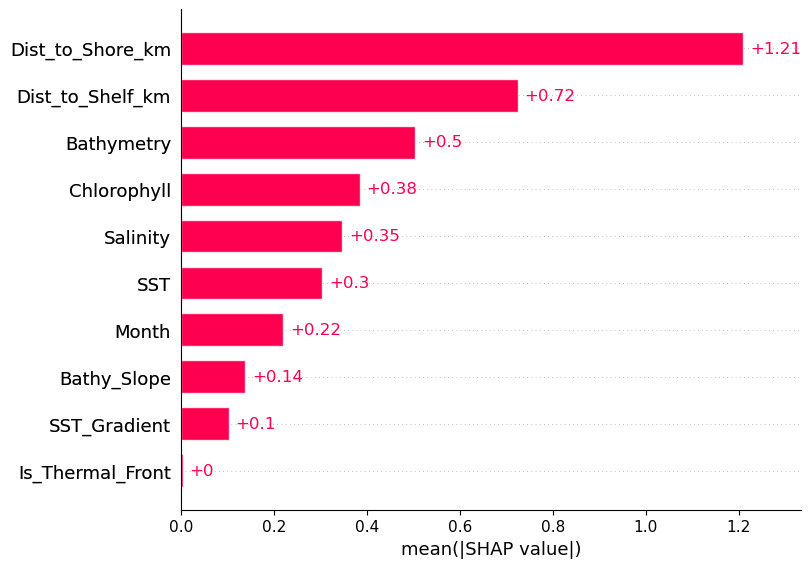

--- XGBoost Beeswarm Summary Plot ---


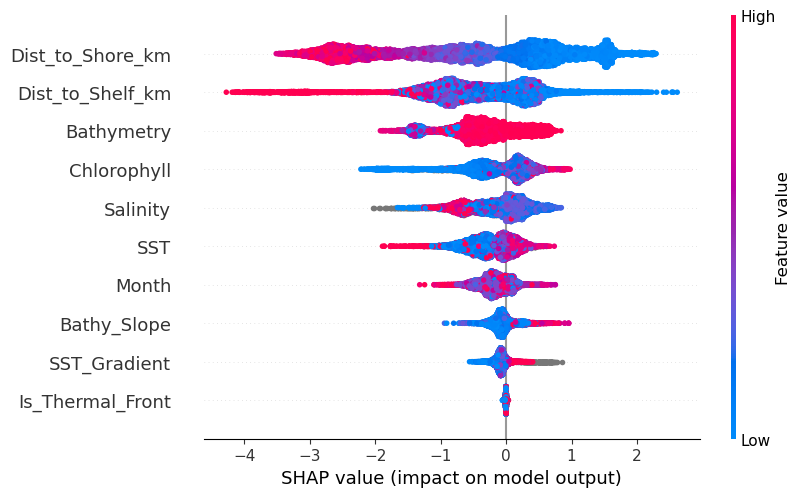

--- XGBoost Dependence Plot (Dist_to_Shore_km) ---


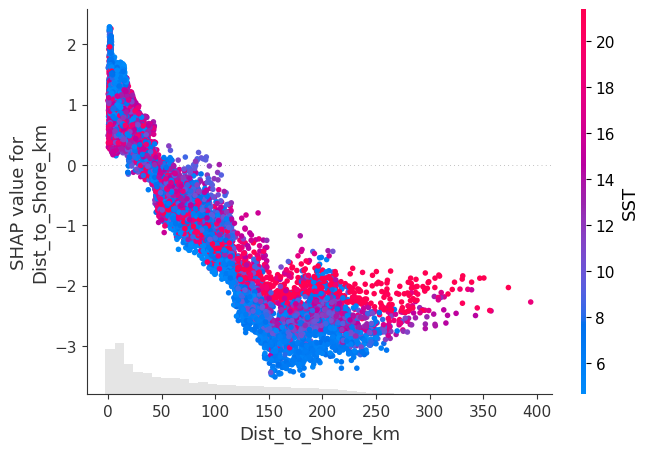

--- XGBoost Waterfall Plot (Local Prediction) ---


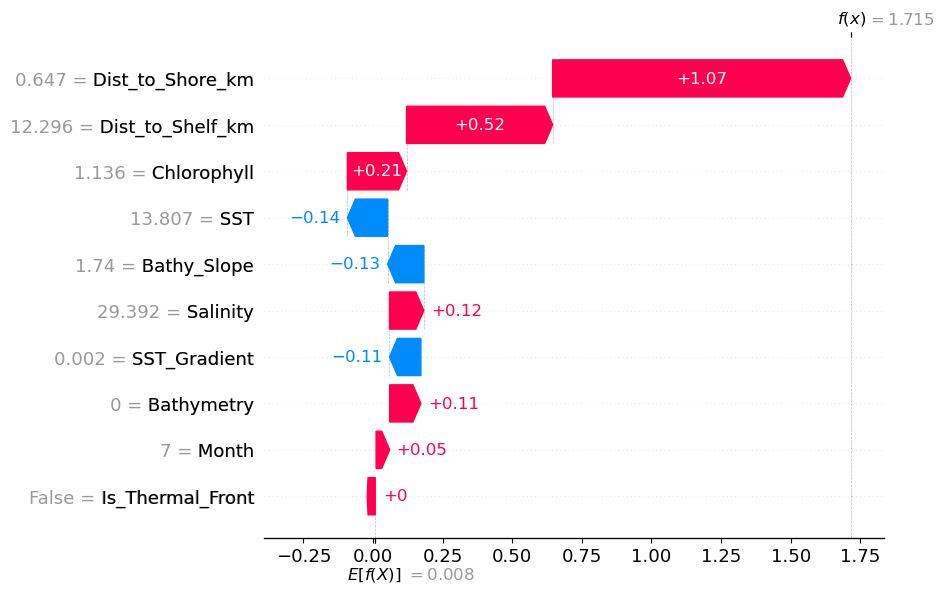

In [4]:
# Load XGBoost model
xgb_model = xgb.XGBClassifier()
xgb_model.load_model("models/xgb_narw_sdm.json")

# Create SHAP explainer
explainer_xgb = shap.TreeExplainer(xgb_model)
shap_values_xgb = explainer_xgb(X_test)

# Plot 1: SHAP Bar Plot (Global Importance)
print("--- XGBoost Global Feature Importance ---")
shap.plots.bar(shap_values_xgb, show=True)

# Plot 2: SHAP Summary Beeswarm Plot
# Shows how high/low values of features push the prediction positive/negative
print("--- XGBoost Beeswarm Summary Plot ---")
shap.plots.beeswarm(shap_values_xgb, show=True)

# Plot 3: SHAP Dependence Plot for the most important feature
# Dist_to_Shore_km is typically the most important feature. 
print("--- XGBoost Dependence Plot (Dist_to_Shore_km) ---")
# shap_values_xgb[:, "Dist_to_Shore_km"] isolates the SHAP values for that feature
shap.plots.scatter(shap_values_xgb[:, "Dist_to_Shore_km"], color=shap_values_xgb, show=True)

# Plot 4: SHAP Waterfall Plot (Local Explanation)
# Explains the specific prediction for our selected whale instance
print("--- XGBoost Waterfall Plot (Local Prediction) ---")
shap.plots.waterfall(shap_values_xgb[local_idx], show=True)


## 2. Random Forest SHAP Analysis
Random Forest is our bagging comparator model. Note that the saved `rf_narw_sdm.joblib` is a Pipeline containing a SimpleImputer and the RandomForestClassifier. We need to apply the imputer to the test data before passing it to the `TreeExplainer`.


--- Random Forest Global Feature Importance ---


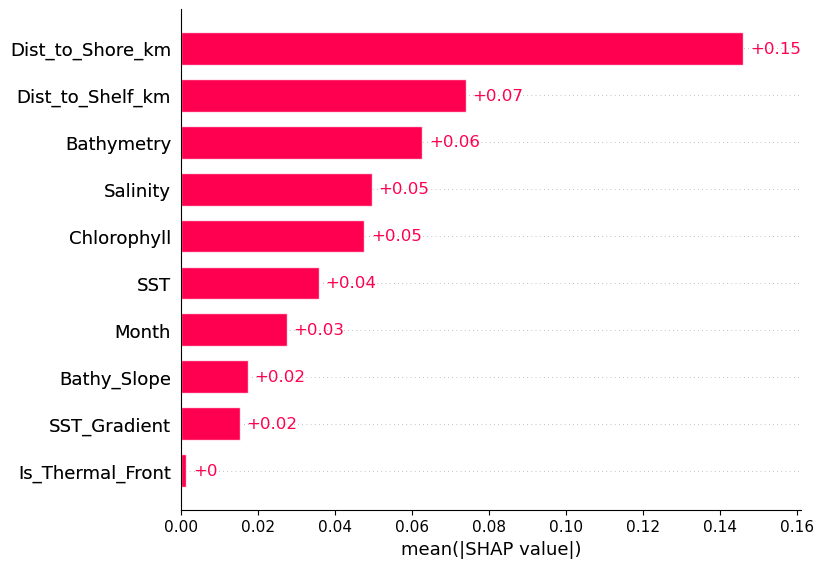

--- Random Forest Beeswarm Summary Plot ---


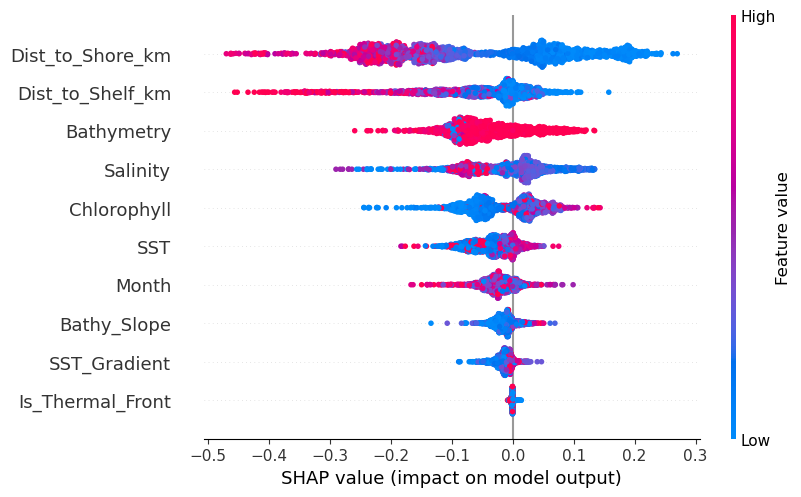

--- Random Forest Dependence Plot (Dist_to_Shore_km) ---


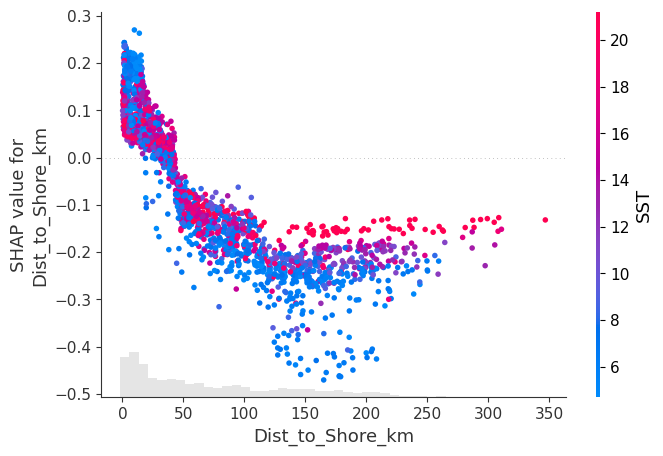

--- Random Forest Waterfall Plot (Local Prediction) ---


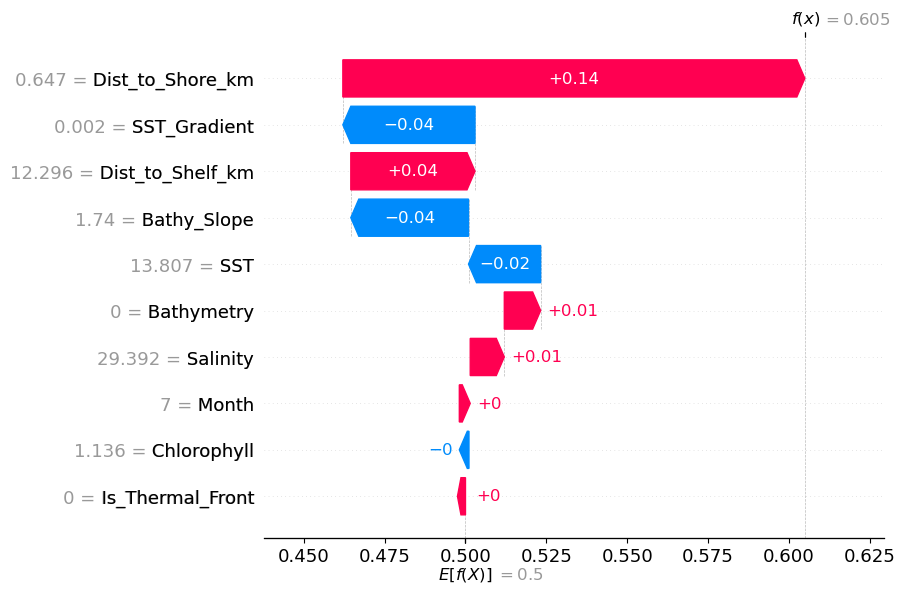

In [5]:
# Load RF Pipeline
rf_pipeline = joblib.load("models/rf_narw_sdm.joblib")
rf_imputer = rf_pipeline.named_steps["imputer"]
rf_clf = rf_pipeline.named_steps["clf"]

# Impute the test data
X_test_imputed_rf = pd.DataFrame(rf_imputer.transform(X_test), columns=X_test.columns)

# --- THE FIX: SUBSAMPLE THE DATA ---
# Take a random sample of 1000 rows to make SHAP finish in seconds/minutes instead of hours.
# We also explicitly include our 'local_idx' so we can still run the waterfall plot on it.
np.random.seed(42)
sample_indices = np.random.choice(X_test_imputed_rf.index, size=2000, replace=False)
if local_idx not in sample_indices:
    sample_indices = np.append(sample_indices, local_idx)

X_rf_sample = X_test_imputed_rf.loc[sample_indices]
# -----------------------------------

# Create SHAP explainer
explainer_rf = shap.TreeExplainer(rf_clf)
shap_values_rf = explainer_rf(X_rf_sample)

# Slice out class 1 (Presence)
if len(shap_values_rf.shape) == 3:
    shap_values_rf_class1 = shap_values_rf[:, :, 1]
else:
    shap_values_rf_class1 = shap_values_rf

# Plot 1: SHAP Bar Plot
print("--- Random Forest Global Feature Importance ---")
shap.plots.bar(shap_values_rf_class1, show=True)

# Plot 2: SHAP Beeswarm Plot
print("--- Random Forest Beeswarm Summary Plot ---")
shap.plots.beeswarm(shap_values_rf_class1, show=True)

# Plot 3: SHAP Dependence Plot
print("--- Random Forest Dependence Plot (Dist_to_Shore_km) ---")
shap.plots.scatter(shap_values_rf_class1[:, "Dist_to_Shore_km"], color=shap_values_rf_class1, show=True)

# Plot 4: SHAP Waterfall Plot
print("--- Random Forest Waterfall Plot (Local Prediction) ---")
# Find the new integer position of our local_idx in the subsample
local_sample_pos = np.where(X_rf_sample.index == local_idx)[0][0]
shap.plots.waterfall(shap_values_rf_class1[local_sample_pos], show=True)


## 3. Logistic Regression SHAP Analysis
Logistic Regression is our linear baseline. The saved pipeline contains an Imputer, a Scaler, and the LogisticRegression model. We use `shap.LinearExplainer` to interpret the linear coefficients and how they apply to specific scaled feature values.


--- Logistic Regression Global Feature Importance ---


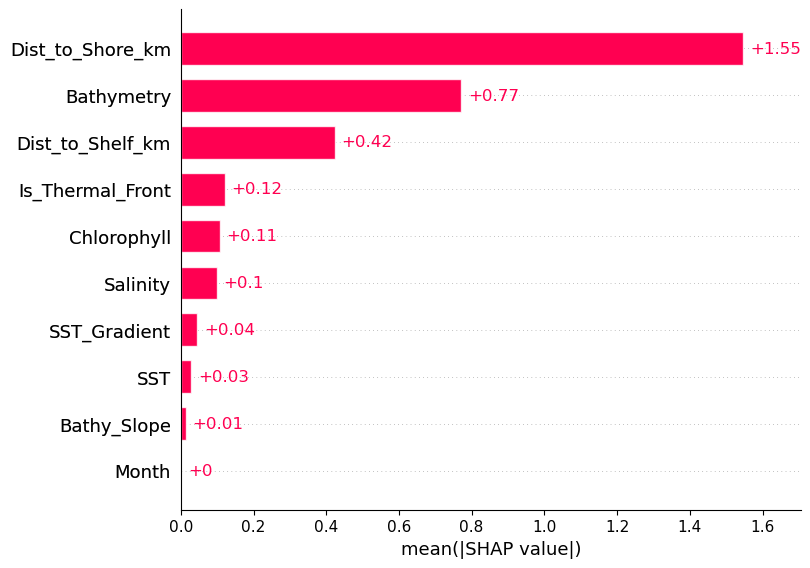

--- Logistic Regression Beeswarm Summary Plot ---


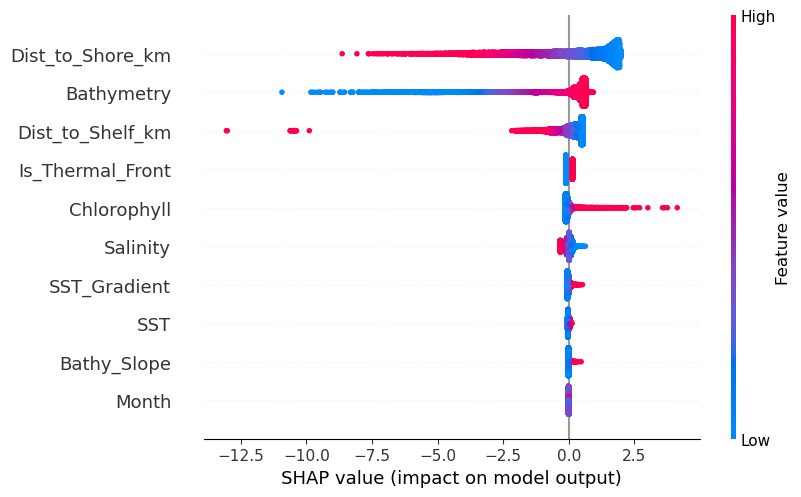

--- Logistic Regression Dependence Plot (Dist_to_Shore_km) ---


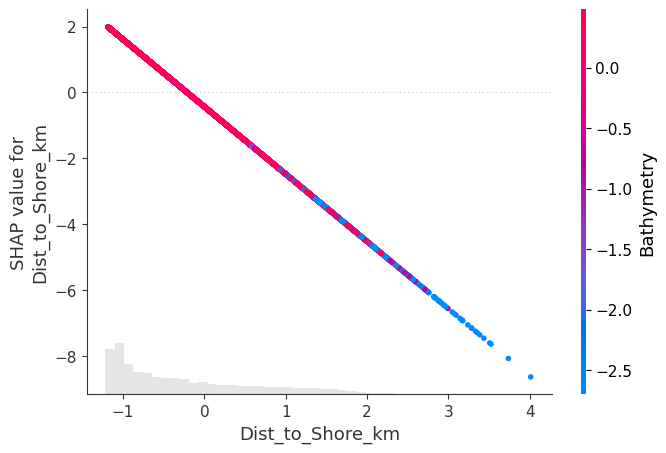

--- Logistic Regression Waterfall Plot (Local Prediction) ---


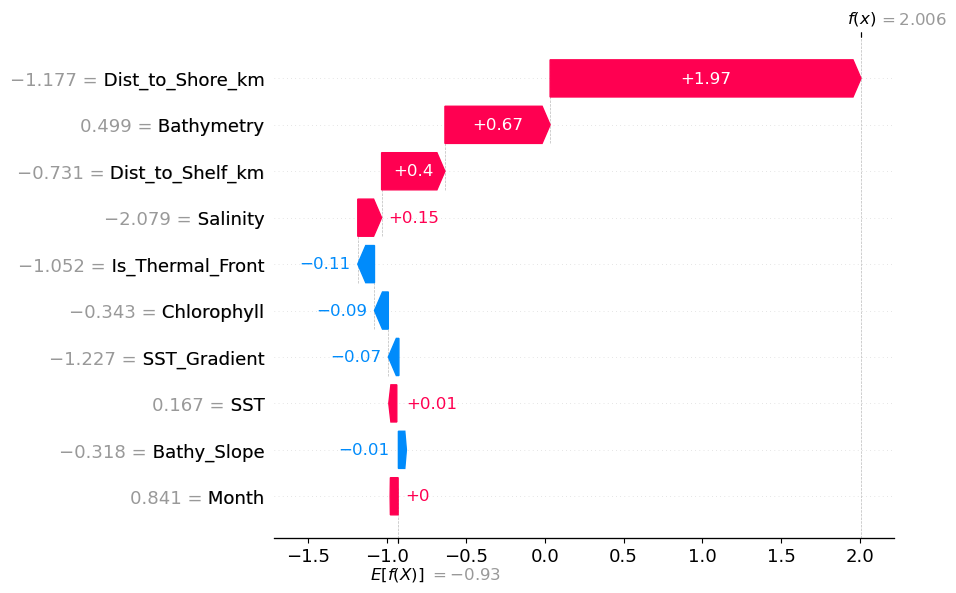

In [6]:
# Load LR Pipeline
lr_pipeline = joblib.load("models/lr_narw_sdm.joblib")
lr_imputer = lr_pipeline.named_steps["imputer"]
lr_scaler = lr_pipeline.named_steps["scaler"]
lr_clf = lr_pipeline.named_steps["clf"]

# Transform the test data
X_test_imputed_lr = lr_imputer.transform(X_test)
X_test_scaled_lr = lr_scaler.transform(X_test_imputed_lr)
X_test_scaled_df = pd.DataFrame(X_test_scaled_lr, columns=X_test.columns)

# Create SHAP explainer for Linear Models
# We use a background dataset (e.g., the test set or a summary of it) for the LinearExplainer
background_data = shap.maskers.Independent(X_test_scaled_df, max_samples=1000)
explainer_lr = shap.LinearExplainer(lr_clf, background_data)
shap_values_lr = explainer_lr(X_test_scaled_df)

# Plot 1: SHAP Bar Plot
print("--- Logistic Regression Global Feature Importance ---")
shap.plots.bar(shap_values_lr, show=True)

# Plot 2: SHAP Beeswarm Plot
print("--- Logistic Regression Beeswarm Summary Plot ---")
shap.plots.beeswarm(shap_values_lr, show=True)

# Plot 3: SHAP Dependence Plot
# In a linear model, the dependence is strictly linear, but we can still visualize it.
print("--- Logistic Regression Dependence Plot (Dist_to_Shore_km) ---")
shap.plots.scatter(shap_values_lr[:, "Dist_to_Shore_km"], color=shap_values_lr, show=True)

# Plot 4: SHAP Waterfall Plot
print("--- Logistic Regression Waterfall Plot (Local Prediction) ---")
shap.plots.waterfall(shap_values_lr[local_idx], show=True)
